# Análisis Exploratorio de Datos

## Objetivo

Explorar el conjunto de datos limpio para identificar patrones, tendencias y relaciones entre las variables asociadas a los accidentes de tránsito ocurridos en el municipio. Los resultados obtenidos servirán como base para la construcción del dashboard interactivo en Power BI.

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)

In [21]:
ruta = Path("../data/processed/accidentes_limpio.csv")

df = pd.read_csv(ruta, parse_dates=["FECHA"])

df.head()

,ORDEN,FECHA,AÑO,MES,GRAVEDAD,PEATON,AUTOMOVIL,CAMPERO,CAMIONETA,MICRO,BUSETA,BUS,CAMION,VOLQUETA,MOTO,BICICLETA,OTRO,BARRIO,HORA,ENTIDAD,COMUNA,Propietario de Vehículo,DIURNO/NOCTURNO,MES_NOMBRE,DIA_SEMANA,DIA_NOMBRE,FIN_DE_SEMANA
0,1,2012-01-01,2012,1,Con heridos,0,1,0,0,0,0,0,0,0,0,0,0,Mutis,12:15:00,AGENTES DTB,17. MUTIS,Particular,Diurno,Enero,6,Domingo,True
1,2,2012-01-01,2012,1,Solo daños,0,1,0,1,0,0,0,0,0,0,0,0,Regaderos Norte,14:00:00,AGENTES DTB,02. NORORIENTAL,Empresa,Diurno,Enero,6,Domingo,True
2,3,2012-01-01,2012,1,Solo daños,0,0,0,1,0,0,0,0,0,0,0,0,Cabecera Del Llano,12:00:00,AGENTES DTB,12. CABECERA DEL LLANO,Particular,Diurno,Enero,6,Domingo,True
3,4,2012-01-01,2012,1,Solo daños,0,1,0,1,0,0,0,0,0,0,0,0,Norte Bajo,18:30:00,AGENTES DTB,03. SAN FRANCISCO,Empresa,Nocturno,Enero,6,Domingo,True
4,5,2012-01-01,2012,1,Con heridos,1,0,0,0,0,0,0,0,0,1,0,0,Dangond,00:30:00,AGENTES DTB,11. SUR,Particular,Nocturno,Enero,6,Domingo,True


# ¿Cuántos accidentes hay por año?

In [22]:
accidentes_anio = df["AÑO"].value_counts().sort_index()

accidentes_anio

AÑO
2012    4342
2013    4054
2014    3724
2015    3765
2016    3739
2017    3812
2018    3917
2019    3716
2020    2261
2021    2719
2022    2220
2023     924
Name: count, dtype: int64

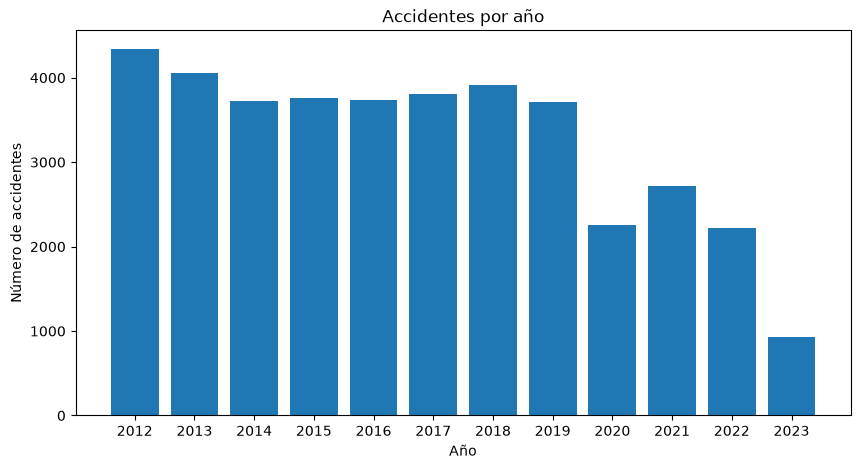

In [23]:
plt.figure(figsize=(10,5))

plt.bar(accidentes_anio.index.astype(str),
        accidentes_anio.values)

plt.title("Accidentes por año")
plt.xlabel("Año")
plt.ylabel("Número de accidentes")

plt.show()

# Hallazgo 1
El número de accidentes registrados se mantiene relativamente estable entre 2012 y 2019, con valores cercanos a los 3.700–4.300 casos anuales.

A partir de 2020 se observa una disminución importante en los registros, la cual podría estar asociada tanto a cambios en la movilidad durante la pandemia como a posibles variaciones en la cobertura o el proceso de reporte de la información.

Por lo tanto, la reducción observada en los últimos años no debe interpretarse automáticamente como una disminución real de la accidentalidad sin contar con información adicional sobre la fuente y metodología de registro.

# ¿Existen meses del año en los que se registran más accidentes de tránsito?

In [24]:
accidentes_mes = (
    df.groupby(["MES", "MES_NOMBRE"])
      .size()
      .reset_index(name="ACCIDENTES")
      .sort_values("MES")
)

accidentes_mes

,MES,MES_NOMBRE,ACCIDENTES
0,1,Enero,3089
1,2,Febrero,3360
2,3,Marzo,3474
3,4,Abril,3123
4,5,Mayo,3462
5,6,Junio,3035
6,7,Julio,3222
7,8,Agosto,3279
8,9,Septiembre,3465
9,10,Octubre,3293


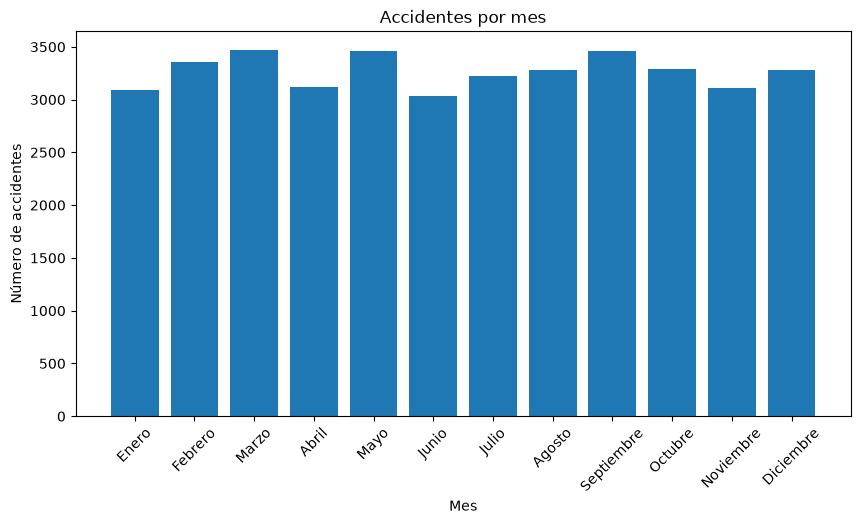

In [25]:
plt.figure(figsize=(10,5))

plt.bar(
    accidentes_mes["MES_NOMBRE"],
    accidentes_mes["ACCIDENTES"]
)

plt.title("Accidentes por mes")
plt.xlabel("Mes")
plt.ylabel("Número de accidentes")

plt.xticks(rotation=45)

plt.show()

In [26]:
mes_max = accidentes_mes.loc[
    accidentes_mes["ACCIDENTES"].idxmax()
]

mes_min = accidentes_mes.loc[
    accidentes_mes["ACCIDENTES"].idxmin()
]

print("Mayor cantidad de accidentes:")
print(mes_max)

print()

print("Menor cantidad de accidentes:")
print(mes_min)

Mayor cantidad de accidentes:
MES               3
MES_NOMBRE    Marzo
ACCIDENTES     3474
Name: 2, dtype: object

Menor cantidad de accidentes:
MES               6
MES_NOMBRE    Junio
ACCIDENTES     3035
Name: 5, dtype: object


In [27]:
porcentaje = (
    accidentes_mes["ACCIDENTES"] /
    accidentes_mes["ACCIDENTES"].sum() * 100
).round(2)

accidentes_mes["PORCENTAJE"] = porcentaje

accidentes_mes

,MES,MES_NOMBRE,ACCIDENTES,PORCENTAJE
0,1,Enero,3089,7.88
1,2,Febrero,3360,8.57
2,3,Marzo,3474,8.86
3,4,Abril,3123,7.97
4,5,Mayo,3462,8.83
5,6,Junio,3035,7.74
6,7,Julio,3222,8.22
7,8,Agosto,3279,8.37
8,9,Septiembre,3465,8.84
9,10,Octubre,3293,8.40


# Hallazgo 3

- La distribución de accidentes a lo largo del año es relativamente uniforme, sin diferencias marcadas entre la mayoría de los meses.
- Los meses de marzo, mayo y septiembre presentan los mayores registros, mientras que junio registra la menor cantidad de accidentes.
- Aunque existen pequeñas variaciones mensuales, estas no son lo suficientemente pronunciadas como para afirmar la existencia de un comportamiento estacional claro.
- Cualquier explicación relacionada con periodos vacacionales, cambios en la movilidad u otros factores externos requiere información adicional, por lo que no puede confirmarse únicamente con este conjunto de datos.

# Accidentes por día de la semana

In [28]:
accidentes_dia = (
    df.groupby(["DIA_SEMANA", "DIA_NOMBRE"])
      .size()
      .reset_index(name="ACCIDENTES")
      .sort_values("DIA_SEMANA")
)

accidentes_dia

,DIA_SEMANA,DIA_NOMBRE,ACCIDENTES
0,0,Lunes,5386
1,1,Martes,5829
2,2,Miércoles,5712
3,3,Jueves,5700
4,4,Viernes,5969
5,5,Sábado,6460
6,6,Domingo,4137


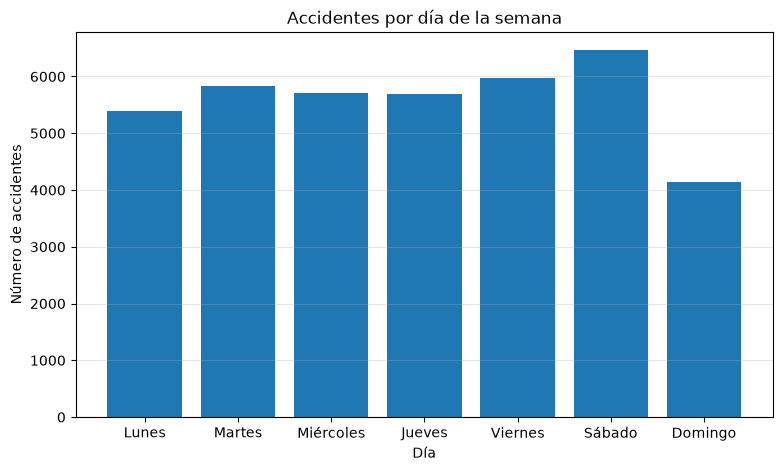

In [29]:
plt.figure(figsize=(9,5))

plt.bar(
    accidentes_dia["DIA_NOMBRE"],
    accidentes_dia["ACCIDENTES"]
)

plt.title("Accidentes por día de la semana")
plt.xlabel("Día")
plt.ylabel("Número de accidentes")

plt.grid(axis="y", alpha=0.3)

plt.show()

# Hallazgo 4
Los sábados y viernes concentran la mayor cantidad de accidentes, mientras que los domingos presentan el menor número de registros.

## Accidentes por hora

In [30]:
df["HORA_NUMERO"] = pd.to_datetime(
    df["HORA"].astype(str),
    errors="coerce"
).dt.hour

C:\Users\joita\AppData\Local\Temp\ipykernel_21992\3602917288.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["HORA_NUMERO"] = pd.to_datetime(


In [31]:
accidentes_hora = (
    df.groupby("HORA_NUMERO")
      .size()
      .reset_index(name="ACCIDENTES")
      .sort_values("HORA_NUMERO")
)

accidentes_hora

,HORA_NUMERO,ACCIDENTES
0,0.0,408
1,1.0,384
2,2.0,411
3,3.0,347
4,4.0,335
5,5.0,644
6,6.0,1457
7,7.0,2039
8,8.0,2062
9,9.0,2018


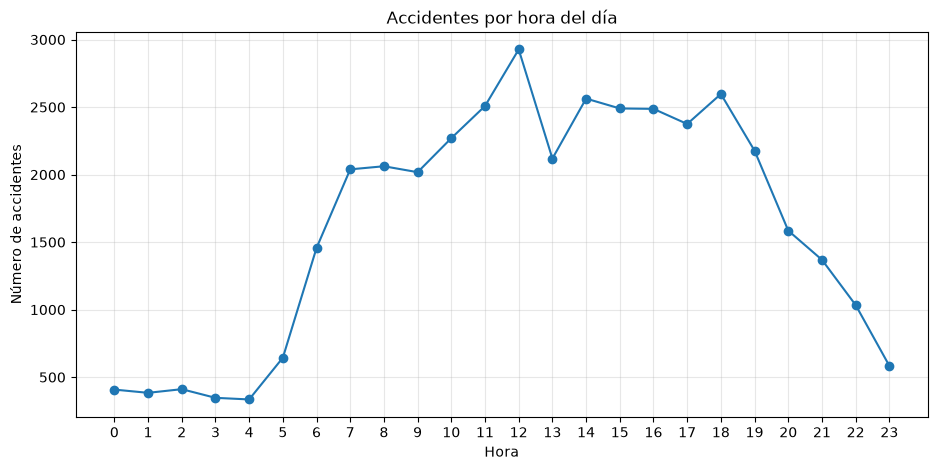

In [32]:
plt.figure(figsize=(11,5))

plt.plot(
    accidentes_hora["HORA_NUMERO"],
    accidentes_hora["ACCIDENTES"],
    marker="o"
)

plt.title("Accidentes por hora del día")
plt.xlabel("Hora")
plt.ylabel("Número de accidentes")

plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.show()

In [33]:
hora_max = accidentes_hora.loc[
    accidentes_hora["ACCIDENTES"].idxmax()
]

hora_min = accidentes_hora.loc[
    accidentes_hora["ACCIDENTES"].idxmin()
]

print("Mayor cantidad de accidentes:")
print(hora_max)

print()

print("Menor cantidad de accidentes:")
print(hora_min)

Mayor cantidad de accidentes:
HORA_NUMERO      12.0
ACCIDENTES     2927.0
Name: 12, dtype: float64

Menor cantidad de accidentes:
HORA_NUMERO      4.0
ACCIDENTES     335.0
Name: 4, dtype: float64


### Hallazgo 5

La distribución de los accidentes por hora muestra un comportamiento claramente diferenciado a lo largo del día. Durante la madrugada (00:00 a 05:00) se registra la menor cantidad de accidentes, mientras que a partir de las 06:00 se observa un incremento progresivo que alcanza su punto máximo a las 12:00.

Entre las 10:00 y las 18:00 la cantidad de accidentes permanece elevada, lo que podría estar relacionado con los periodos de mayor movilidad de la población. Sin embargo, esta interpretación requiere información adicional sobre el flujo vehicular para ser confirmada.

# Gravedad del accidente según tipo de propietario del vehículo

In [34]:
df["Propietario de Vehículo"].value_counts()

Propietario de Vehículo
Particular    27981
Empresa       11212
Name: count, dtype: int64

In [35]:
tabla_gravedad = pd.crosstab(
    df["Propietario de Vehículo"],
    df["GRAVEDAD"]
)

tabla_gravedad

GRAVEDAD,Con heridos,Con muertos,Solo daños
Propietario de Vehículo,,,
Empresa,4525,175,6512
Particular,14457,434,13090


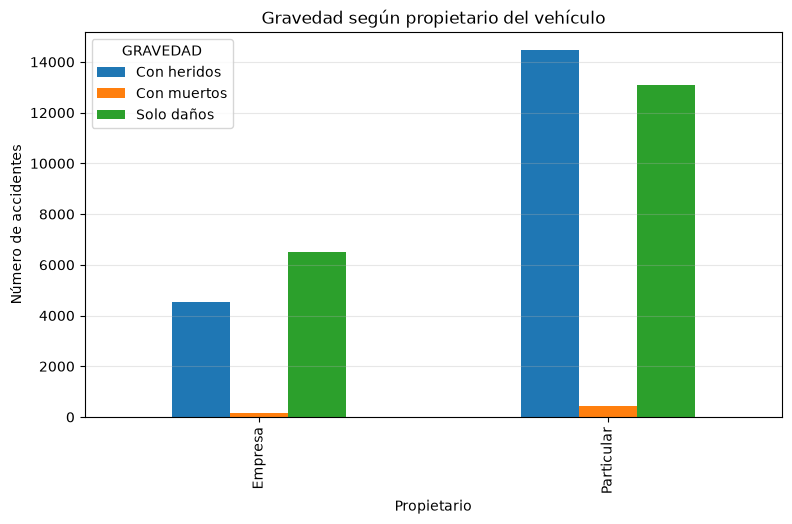

In [36]:
tabla_gravedad.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Gravedad según propietario del vehículo")
plt.xlabel("Propietario")
plt.ylabel("Número de accidentes")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [37]:
tabla_porcentaje = pd.crosstab(
    df["Propietario de Vehículo"],
    df["GRAVEDAD"],
    normalize="index"
) * 100

tabla_porcentaje.round(2)

GRAVEDAD,Con heridos,Con muertos,Solo daños
Propietario de Vehículo,,,
Empresa,40.36,1.56,58.08
Particular,51.67,1.55,46.78


### Hallazgo 6

Al comparar la gravedad de los accidentes según el propietario del vehículo, se observa que los vehículos empresariales presentan una mayor proporción de accidentes con solo daños materiales (58.08%), mientras que los vehículos particulares registran una mayor proporción de accidentes con personas heridas (51.67%).

En cuanto a los accidentes con víctimas fatales, ambos grupos presentan porcentajes prácticamente iguales (1.56% y 1.55%), por lo que no se evidencia una diferencia significativa entre ellos con la información disponible.

Las diferencias observadas podrían estar relacionadas con factores como el uso del vehículo, el tipo de operación o los patrones de movilidad, aunque estas hipótesis requerirían información adicional para ser confirmadas.

# Gravedad según la hora
¿En qué horas del día se concentran los accidentes con heridos o fallecidos?

In [38]:
gravedad_hora = pd.crosstab(
    df["HORA_NUMERO"],
    df["GRAVEDAD"]
)

gravedad_hora

GRAVEDAD,Con heridos,Con muertos,Solo daños
HORA_NUMERO,,,
0.0,223,20,165
1.0,216,23,145
2.0,207,21,183
3.0,170,23,154
4.0,179,15,141
5.0,367,24,253
6.0,850,20,587
7.0,1110,27,902
8.0,1012,24,1026


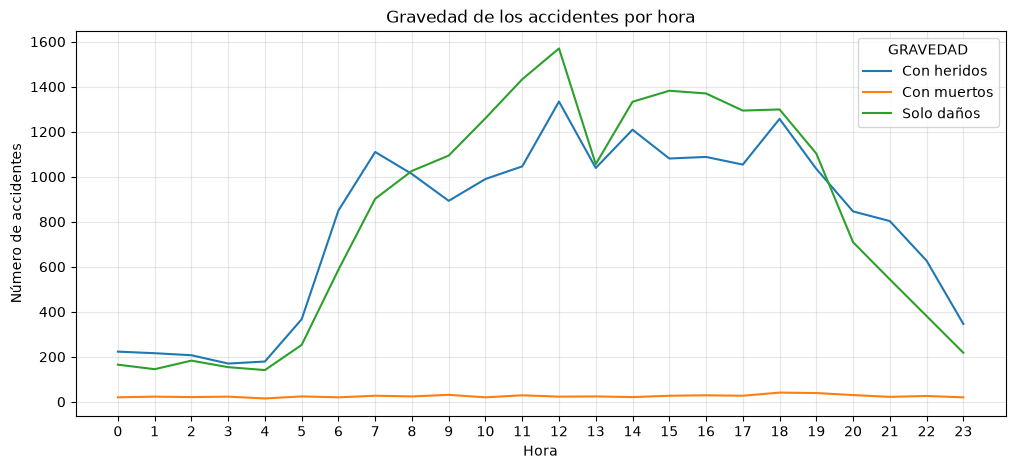

In [39]:
gravedad_hora.plot(
    figsize=(12,5)
)

plt.title("Gravedad de los accidentes por hora")
plt.xlabel("Hora")
plt.ylabel("Número de accidentes")

plt.xticks(range(24))

plt.grid(alpha=0.3)

plt.show()

### Hallazgo 7

El comportamiento de la gravedad de los accidentes varía a lo largo del día. Los accidentes con solo daños materiales y con personas heridas presentan un patrón muy similar al observado en el total de accidentes, incrementándose desde las primeras horas de la mañana y alcanzando su mayor concentración alrededor del mediodía.

En contraste, los accidentes con víctimas fatales no muestran un patrón tan marcado debido a su baja frecuencia. No obstante, se observa un ligero incremento durante las últimas horas de la tarde, registrando su mayor número de casos alrededor de las 18:00.

Estos resultados sugieren que, aunque el mayor volumen de accidentes ocurre durante las horas de mayor movilidad, la ocurrencia de accidentes fatales podría estar influenciada por otros factores distintos al flujo vehicular, los cuales no pueden analizarse con la información disponible en este conjunto de datos.

¿Los accidentes del fin de semana son más graves?

In [41]:
pd.crosstab(
    df["FIN_DE_SEMANA"],
    df["GRAVEDAD"],
    normalize="index"
) * 100

GRAVEDAD,Con heridos,Con muertos,Solo daños
FIN_DE_SEMANA,,,
False,47.149951,1.314869,51.53518
True,51.892045,2.198735,45.90922


### Hallazgo 8

La gravedad de los accidentes presenta diferencias entre los días laborales y los fines de semana. Mientras que entre semana predominan los accidentes con solo daños materiales (51.54%), durante los fines de semana aumenta la proporción de accidentes con personas heridas (51.89%) y de accidentes con víctimas fatales (2.20%).

En particular, la proporción de accidentes con víctimas fatales es notablemente mayor durante los fines de semana que en los días laborales, lo que sugiere un cambio en el comportamiento de la severidad de los accidentes según el periodo de la semana.

Este comportamiento podría estar asociado a factores como cambios en los patrones de movilidad, actividades recreativas o condiciones de conducción propias de los fines de semana. Sin embargo, estas hipótesis no pueden confirmarse únicamente con la información disponible en este conjunto de datos.

## tipo de vehiculo
Que tipo de vehiculos estan mas involucrados en accidentes con heridos, muertos o solo daños.

In [42]:
vehiculos = [
    "PEATON",
    "AUTOMOVIL",
    "CAMPERO",
    "CAMIONETA",
    "MICRO",
    "BUSETA",
    "BUS",
    "CAMION",
    "VOLQUETA",
    "MOTO",
    "BICICLETA",
    "OTRO"
]

In [43]:
accidentes_vehiculo = (
    df.groupby("GRAVEDAD")[vehiculos]
      .sum()
      .T
)

accidentes_vehiculo

GRAVEDAD,Con heridos,Con muertos,Solo daños
PEATON,3909,220,7
AUTOMOVIL,9595,143,20882
CAMPERO,610,7,1749
CAMIONETA,2155,49,5520
MICRO,248,10,537
BUSETA,488,24,1202
BUS,528,34,1322
CAMION,669,91,2506
VOLQUETA,98,18,434
MOTO,19191,481,4887


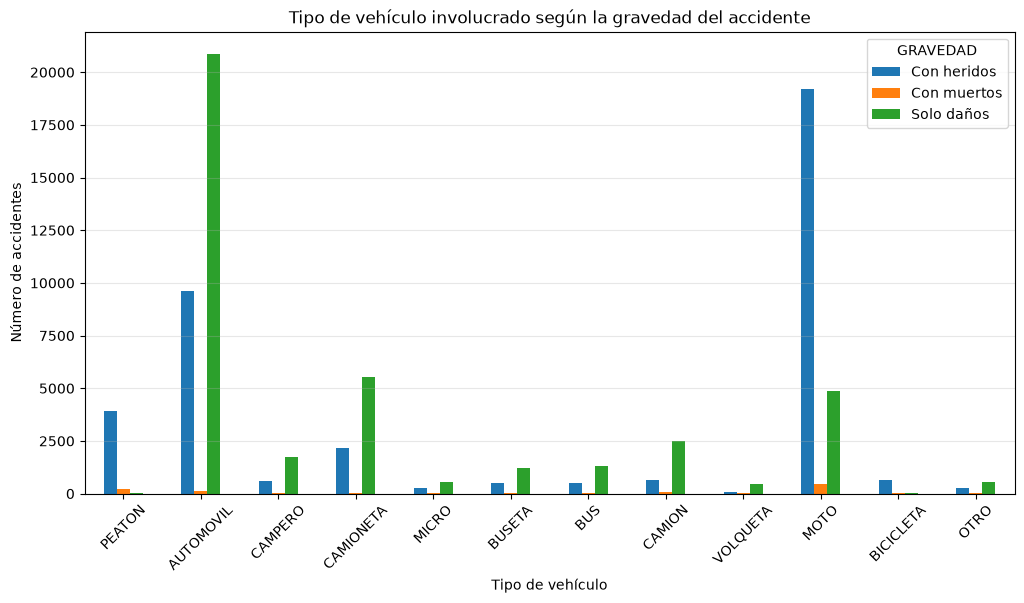

In [44]:
accidentes_vehiculo.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Tipo de vehículo involucrado según la gravedad del accidente")
plt.xlabel("Tipo de vehículo")
plt.ylabel("Número de accidentes")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [45]:
for gravedad in accidentes_vehiculo.columns:
    vehiculo = accidentes_vehiculo[gravedad].idxmax()
    cantidad = accidentes_vehiculo[gravedad].max()

    print(f"{gravedad}: {vehiculo} ({cantidad} accidentes)")

Con heridos: MOTO (19191 accidentes)
Con muertos: MOTO (481 accidentes)
Solo daños: AUTOMOVIL (20882 accidentes)


### Hallazgo 9

El análisis por tipo de vehículo muestra diferencias importantes en la gravedad de los accidentes.

Las motocicletas son el tipo de vehículo con mayor participación en accidentes con personas heridas (19.191 registros) y con víctimas fatales (481 registros), mientras que los automóviles predominan en los accidentes que ocasionan únicamente daños materiales (20.882 registros).

Asimismo, los peatones y las bicicletas presentan una participación muy reducida en accidentes clasificados como "solo daños", lo que indica que cuando estos usuarios se ven involucrados en un accidente, con frecuencia existen consecuencias para la integridad física de las personas.

Es importante señalar que estos resultados representan la participación de cada tipo de vehículo en los accidentes registrados y no permiten establecer cuál de ellos fue el responsable del siniestro.